## Supervised Learning Premier

<p>
The quality of data and the amount of useful information it contains is very key to the results of the machine learning algorithms.
Its important to examine and preprocess data before feeding the data to machine learning algorithms
</p>

In [36]:
import pandas as pd
from io import StringIO

import warnings
warnings.filterwarnings("ignore")

In [3]:
csv_data = '''
A,B,C,D
1.0, 2.0, 3.0, 4.0
5.0,6.0,8.0
10.0,11.0,12.0,
'''
df = pd.read_csv(StringIO(csv_data))
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,8.0,NaN
2,10.0,11.0,12.0,NaN


In [4]:
df.isnull().sum()

A    0
B    0
C    0
D    2
dtype: int64

In [5]:
## drop rows with missing values 
df.dropna(axis = 0)

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [6]:
## drop rows with missing values based on a certain column

df.dropna(subset=['D'], axis =0)

,A,B,C,D
0,1.0,2.0,3.0,4.0


<p>We can also drop columns that have atleast one NaN in any row</p>

In [7]:
df.dropna(axis =1)

,A,B,C
0,1.0,2.0,3.0
1,5.0,6.0,8.0
2,10.0,11.0,12.0


<p>
The danger of dropping NaN or missing data is that we can end up removing a lot of samples, which could leave us with
less than meaninful data to proceed with our modelling or to even learn fom the data.
</p>

<h3>Imputing Missing Values</h3>

<p>To avoid losing too much valuable data, we can adop another approach that interpolates numerical data hence 
replacing the missing values</p>

In [8]:
from sklearn.impute import SimpleImputer

In [9]:
imputer = SimpleImputer(strategy = 'mean',)
imputer.fit(df)

SimpleImputer()

In [10]:
imputer.statistics_

array([5.33333333, 6.33333333, 7.66666667, 4.        ])

In [11]:
#df.mean().values

In [12]:
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,8.0,NaN
2,10.0,11.0,12.0,NaN


In [13]:
X = imputer.transform(df)

In [14]:
new_df = pd.DataFrame(X, columns = df.columns)
new_df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,8.0,4.0
2,10.0,11.0,12.0,4.0


<p>We replaced each null value with the mean, which has been computed for each column</p>

### Dealing with categorical data

<p>
Categorical data can be classified into ordinal and nominal data.
</p>

<p>Ordinal features: Are categorical values that can be ordered/ arranged/ sorted. For example a t-shirt size can be XL > L > M > S </p>
    

<p>Nominal features: Do not imply any order, for example it could be color, or Language type, we cannot say one is larger os smaller than the other</p>

In [15]:
df = pd.DataFrame([['Green', 'M', 10.1, 'class1'],
                 ['Red','L', 13.5, 'class2'],
                 ['Blue','XL',15.3, 'class1']])
df.columns = ['color', 'size', 'price','class_label']
df

,color,size,price,class_label
0,Green,M,10.1,class1
1,Red,L,13.5,class2
2,Blue,XL,15.3,class1


### Let's try to map ordinal categorical variables using an assumption, for example: 

XL = L + 1 = M + 2

In [16]:
size_mapping = {
    'XL': 3,
    'L' : 2,
    'M' : 1
}
df['size'] = df['size'].map(size_mapping)

In [17]:
df

,color,size,price,class_label
0,Green,1,10.1,class1
1,Red,2,13.5,class2
2,Blue,3,15.3,class1


#### If we want to reverse the mapping, this is what we can do

In [18]:
inverse_mapping = {v: k for k, v in size_mapping.items()} ## dictionary comprehension to produce another dictionary
df['size_r'] = df['size'].map(inverse_mapping)

In [19]:
df

,color,size,price,class_label,size_r
0,Green,1,10.1,class1,M
1,Red,2,13.5,class2,L
2,Blue,3,15.3,class1,XL


## Notes:

<p>
The zip() function is used to combine multiple iterables such as lists,
dictionaries and tuples into iterator of tuple. Each tuple will contain 
corresponding elements from the input iterables.
</p>

In [20]:
names = ["Fred","Alice","Andrew"]
scores = [78, 89, 78]

score_each = dict(zip(names, scores))

In [21]:
score_each

{'Fred': 78, 'Alice': 89, 'Andrew': 78}

In [22]:
paired = list(zip(names, scores))
print(paired)

[('Fred', 78), ('Alice', 89), ('Andrew', 78)]


In [23]:
### Unpacking a zipped object

names, scores = zip(*paired)
print(names)
print(scores)

('Fred', 'Alice', 'Andrew')
(78, 89, 78)


In [24]:
for name, score in zip(names, scores):
    print(f'{name} scored {score}')

Fred scored 78
Alice scored 89
Andrew scored 78


###### Handling unequal length variable iterables using: zip_longest

In [25]:
from itertools import zip_longest
list1 = [10, 45, 78]
list2 = ['A','B']

result = list(zip_longest(list1, list2, fillvalue ='N/A'))
print(result)

[(10, 'A'), (45, 'B'), (78, 'N/A')]


In [26]:
list(zip(list1, list2))

## as we can see above that zip will stop at the shortest one, and will not combine the iterables whose length has not been matched

[(10, 'A'), (45, 'B')]

#### Encoding class labels

In [27]:
import numpy as np
class_mapping = {label : idx for idx, label in enumerate(np.unique(df['class_label']))}
class_mapping

{'class1': 0, 'class2': 1}

In [28]:
df['class_label_ecoded'] = df['class_label'].map(class_mapping)
df

,color,size,price,class_label,size_r,class_label_ecoded
0,Green,1,10.1,class1,M,0
1,Red,2,13.5,class2,L,1
2,Blue,3,15.3,class1,XL,0


In [29]:
### An alternative way to do this is using SciKit learn, LbelEncoder

In [30]:
from sklearn.preprocessing import LabelEncoder ## mostly to encode class labels
from sklearn.preprocessing import OneHotEncoder

class_le = LabelEncoder()
y = class_le.fit_transform(df['class_label'])
y

array([0, 1, 0])

In [31]:
from sklearn.preprocessing import OneHotEncoder
colors = df[['color']]
encoder = OneHotEncoder()
color_encoded = encoder.fit_transform(colors)
color_encoded

<3x3 sparse matrix of type '<class 'numpy.float64'>'
	with 3 stored elements in Compressed Sparse Row format>

In [32]:
color_encoded.toarray()

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

##### Another way to create the one-hot encoded features is by using Pandas' get_dummies method

In [33]:
pd.get_dummies(df[['price','color','size']],dtype=float,drop_first =True)

,price,size,color_Green,color_Red
0,10.1,1,1.0,0.0
1,13.5,2,0.0,1.0
2,15.3,3,0.0,0.0


###### To reduce correlation among variables, we can remove one feature column from the one-hot encoded array

## Logistic Regression

In real world machine learning, determining whether classes are linearly separable or non-linearly separable is crucial for selecting
the right model to use.

To know whether classes are linearly separable, we can either plot using scatter plots or pair plots, to determine the separability of the classes.

Another way to know whether the classes are linearly separable, is by applying the model, and testing the accuracy of the model. If the accuracy is high, then perhaps the classes are linearly 
separable, if the accuracy is low, then the classes are non-linearly separable, and we should therefore use other models.

Logistic regression works by computing the probability that an instance belongs to a certain class. It is a binary classifier
which works well on linearly separable classes.

Text(0, 0.5, '$\\phi (z)$')

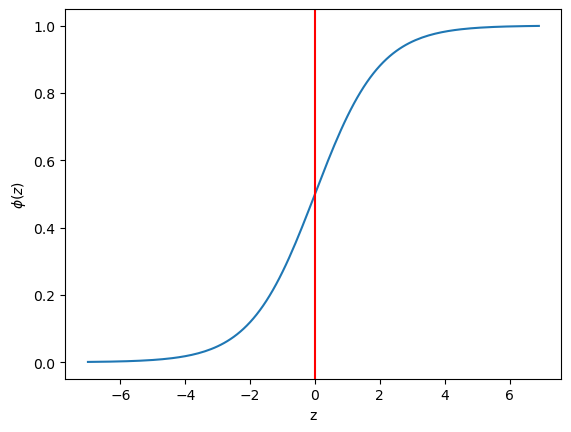

In [37]:
import matplotlib.pyplot as plt
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
phi_z = sigmoid(z)
plt.plot(z, phi_z)
plt.axvline(0.0, color = 'r')
plt.xlabel('z')
plt.ylabel('$\phi (z)$')

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn import datasets

iris = datasets.load_iris()

In [39]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [40]:
target_names = list(iris["target_names"])
target_data = list(iris["target"])

In [41]:
target_names

['setosa', 'versicolor', 'virginica']

In [42]:
target_map = {
    0: target_names[0],
    1: target_names[1],
    2: target_names[2]
}

In [43]:
target_map

{0: 'setosa', 1: 'versicolor', 2: 'virginica'}

In [44]:
target_data_mapped = pd.Series(target_data, name='class_names').map(target_map)
target_data_raw = pd.Series(target_data, name ='classes')

In [45]:
X = iris['data']
X.shape

(150, 4)

In [46]:
y = iris['target']
y.shape

(150,)

In [47]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [48]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

split = StratifiedShuffleSplit(n_splits =1, test_size=0.2, random_state = 42)
for train_idx, test_idx in split.split(X,y):
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

In [49]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [50]:
log_reg = LogisticRegression(C=100, random_state = 42)
log_reg.fit(X_train_std, y_train)

LogisticRegression(C=100, random_state=42)

In [51]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

In [52]:
log_reg.predict_proba(X_test_std)

array([[9.99924476e-01, 7.55239157e-05, 2.56768579e-21],
       [2.52948685e-06, 2.93944003e-01, 7.06053467e-01],
       [3.38434738e-02, 9.66155809e-01, 7.17151839e-07],
       [9.94304094e-03, 9.90055922e-01, 1.03699993e-06],
       [9.99980144e-01, 1.98561960e-05, 2.66258012e-22],
       [5.59774308e-05, 9.87501933e-01, 1.24420892e-02],
       [9.99997168e-01, 2.83196200e-06, 7.73261364e-25],
       [9.96876039e-01, 3.12396109e-03, 5.38095201e-20],
       [2.53847699e-09, 9.91753151e-03, 9.90082466e-01],
       [2.74367507e-03, 9.83840621e-01, 1.34157039e-02],
       [1.38887275e-13, 2.60423104e-04, 9.99739577e-01],
       [2.28039140e-11, 1.24679935e-03, 9.98753201e-01],
       [1.24487103e-12, 2.47753485e-05, 9.99975225e-01],
       [3.16439057e-05, 9.98364284e-01, 1.60407181e-03],
       [9.99771313e-01, 2.28686684e-04, 1.93430632e-21],
       [9.99614663e-01, 3.85337176e-04, 2.85611344e-21],
       [9.99719482e-01, 2.80518441e-04, 9.23007822e-24],
       [3.33655130e-04, 9.99642

In [53]:
predictions =  log_reg.predict(X_test_std)

#### Pipeline estimators

In [54]:
from sklearn.pipeline import Pipeline, make_pipeline

In [55]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data", header = None)


In [56]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [57]:
from sklearn.preprocessing import LabelEncoder

X = df.loc[:, 2:].values
y = df.loc[:,1].values
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['B', 'M'], dtype=object)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 42, stratify = y, test_size = 0.2)

In [59]:
y_train.shape

(455,)

In [60]:
X_train.shape

(455, 30)

###### ---> Combining transformers and estimators in a pipeline

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(),
                        PCA(n_components=2),
                       LogisticRegression(random_state =42))

In [62]:
transform_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
    ('pca',PCA(n_components =2))
])
X_transformed = transform_pipeline.fit_transform(X_train)

In [63]:
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)

In [64]:
print('Test Accuracy: %.3f' % pipe_lr.score(X_test, y_test))

Test Accuracy: 0.947


In [65]:
X_train.shape

(455, 30)

In [66]:
y_train.shape

(455,)

#### Cross validation techniques

In [67]:
fold = StratifiedKFold(n_splits =10)
fold.get_n_splits(X_train, y_train)

10

In [68]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, KFold


s_kfold = StratifiedKFold(n_splits = 10).split(X_train, y_train)
model_scores = []
for k, (train_idx, validation_idx) in enumerate(s_kfold):
    pipe_lr.fit(X_train[train_idx], y_train[train_idx])
    score = pipe_lr.score(X_train[validation_idx], y_train[validation_idx])
    model_scores.append(score)
    print('Fold: %2d, Class dist: %s, Accuracy: %.3f' % (k+1, np.bincount(y_train[train_idx]), score))

Fold:  1, Class dist: [256 153], Accuracy: 0.957
Fold:  2, Class dist: [256 153], Accuracy: 0.913
Fold:  3, Class dist: [256 153], Accuracy: 0.978
Fold:  4, Class dist: [256 153], Accuracy: 1.000
Fold:  5, Class dist: [256 153], Accuracy: 0.935
Fold:  6, Class dist: [257 153], Accuracy: 0.911
Fold:  7, Class dist: [257 153], Accuracy: 0.911
Fold:  8, Class dist: [257 153], Accuracy: 0.978
Fold:  9, Class dist: [257 153], Accuracy: 0.911
Fold: 10, Class dist: [257 153], Accuracy: 0.956


In [69]:
print('\n K-Fold CV Accuracy : %.3f +/- %.3f' % (np.mean(model_scores), np.std(model_scores)))


 K-Fold CV Accuracy : 0.945 +/- 0.032


In [70]:
X_train.shape

(455, 30)

In [71]:
pipe_lr

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=2)),
                ('logisticregression', LogisticRegression(random_state=42))])

In [72]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(estimator = pipe_lr, X = X_train, y = y_train, cv=10, n_jobs = 1) ## Changed n_jobs = 1 from n_jobs =2
print('CV accuracy: %s' % scores)
print('\n CV Accuracy : %.3f +/- %.3f' % (np.mean(scores), np.std(scores)))

CV accuracy: [0.95652174 0.91304348 0.97826087 1.         0.93478261 0.91111111
 0.91111111 0.97777778 0.91111111 0.95555556]

 CV Accuracy : 0.945 +/- 0.032


## Learning and Validation Curves

### Learning Curves - Diagnosing bias and variance

In [126]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

pipe_lr = make_pipeline(StandardScaler(),
                       LogisticRegression(penalty = 'l2'))

train_sizes, train_scores, test_scores = learning_curve(estimator = pipe_lr,
                                                       X = X_train,
                                                       y = y_train,
                                                       train_sizes = np.linspace(0.1, 1.0, 10),
                                                       cv = 10,
                                                       n_jobs = 1)

train_mean = np.mean(train_scores, axis = 1)
train_std = np.std(train_scores, axis = 1)
validation_mean = np.mean(test_scores, axis = 1)
validation_std = np.std(test_scores, axis = 1)

In [129]:
train_mean.shape

(10,)

In [133]:
val_std = np.array([0.002]* 10,dtype=float)

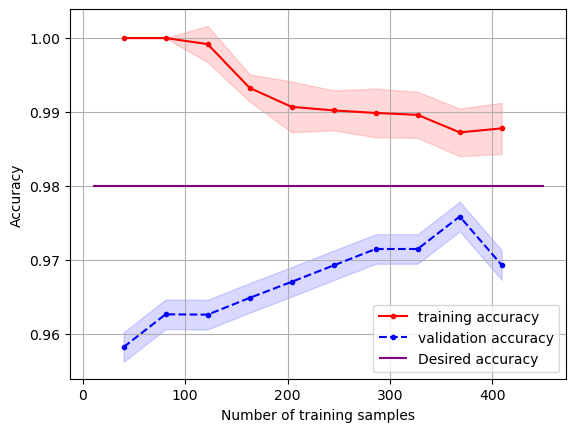

In [134]:
plt.plot(train_sizes, train_mean, color = 'red', marker = 'o', markersize = 3, label = 'training accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha = 0.15, color='red')
plt.plot(train_sizes, validation_mean, color = 'blue', marker = 'o',linestyle='--', markersize = 3, label ='validation accuracy')
plt.fill_between(train_sizes, validation_mean + val_std,validation_mean - val_std, alpha = 0.15, color = 'blue')
plt.hlines(y=0.98, xmin = 10, xmax=450, linestyles = 'solid', color ='purple', label = 'Desired accuracy')
plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

##### What the learning curve tells us: 

- Below 350 training samples, the model has high training accuracy and low validation accuracy. There is a huge gap between training and validation accuracy. This indicates that with 350 samples, the model overfits at that point.

- With less that 200 training samples, the model overfits severely.

- With more than 350 training samples, the training and validation accuracy are converging, showing that the model is starting to generalize well on the unseen data

### Validation Curves - addressing overfiting and underfiting related issues

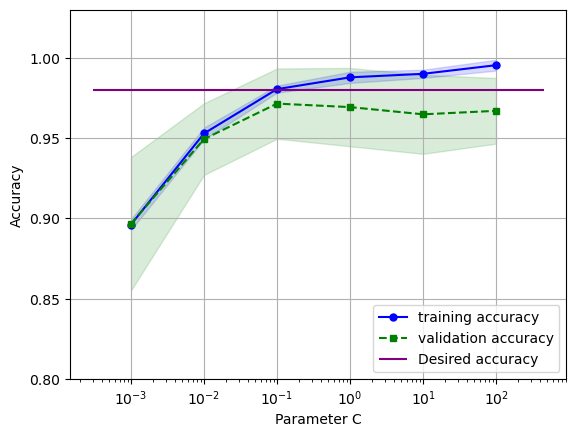

In [75]:
from sklearn.model_selection import validation_curve

param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_scores, test_scores = validation_curve(estimator = pipe_lr,
                                            X = X_train,
                                            y = y_train,
                                            param_name = 'logisticregression__C',
                                            param_range = param_range,
                                            cv = 10)
train_mean = np.mean(train_scores, axis =1)
train_std = np.std(train_scores, axis =1)
test_mean = np.mean(test_scores, axis =1)
test_std = np.std(test_scores, axis =1)
plt.plot(param_range, train_mean, color = 'blue', marker = 'o', markersize =5, label='training accuracy')
plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha = 0.15, color = 'blue')
plt.plot(param_range, test_mean, color = 'green', linestyle ='--', marker='s', markersize=5, label='validation accuracy')
plt.fill_between(param_range, test_mean + test_std, test_mean - test_std, alpha = 0.15, color ='green')
plt.hlines(y=0.98, xmin = 0.0003, xmax=450, linestyles = 'solid', color ='purple', label = 'Desired accuracy')
plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')
plt.ylim([0.8, 1.03])
plt.show()

#### What does the validation curve tell us ?

In the validation curve above, we have plotted the training and validation accuracy of the Logistic
Regression model against the parameter C, inverse regularization over a range of values.

We can see that the model slightly underfits the data when the values of C are too small (increase regularization strength)

And the model overfits the data when we increase the value of C (weaken the regularization).

In this case, it seems that the perfect C occurs between 0.01 and 0.1



## Fine Tuning via GridSearch

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(),
                      SVC(random_state = 1))

param_range = [0.0001, 0.0001,0.001, 0.01, 0.1,10,10.0,100.0,1000.0]
param_grid = [{'svc__C':param_range, 'svc__kernel': ['linear']},
              {'svc__C':param_range, 'svc__gamma': param_range,'svc__kernel':['rbf']}]
gs = GridSearchCV(estimator = pipe_svc, param_grid = param_grid, scoring = 'accuracy', cv=10, n_jobs = 1)


In [77]:
gs = gs.fit(X_train, y_train)

In [78]:
print(gs.best_score_)

0.9757004830917875


In [79]:
print(gs.best_params_)

{'svc__C': 100.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


In [80]:
print(gs.best_estimator_)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=100.0, gamma=0.01, random_state=1))])


In [81]:
clf = gs.best_estimator_
clf.fit(X_train, y_train)
print('Test accuracy: %.3f' % clf.score(X_test, y_test))

Test accuracy: 0.956


### Performance Evaluation

In [82]:
from sklearn.metrics import confusion_matrix

gs.fit(X_train, y_train)
y_preds = gs.predict(X_test)
conf_matrix = confusion_matrix(y_true = y_test, y_pred = y_preds)
print(conf_matrix)

[[70  2]
 [ 3 39]]


In [83]:
conf_matrix.shape[1]

2

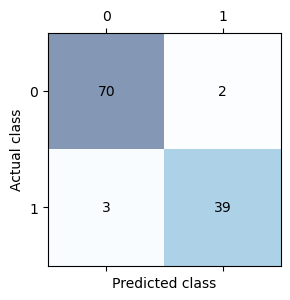

In [84]:
fig, ax = plt.subplots(figsize = (3, 5))
ax.matshow(conf_matrix, cmap = plt.cm.Blues, alpha = 0.5)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x =j, y=i, s = conf_matrix[i,j], va ='center', ha = 'center')
        
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.show()

#### Dimistifying the confusion matrix

<p>Class 1 represents the Malignant case</p>

<p>Class 0 represents the Benign case</p>

<p>The classifier identified 39 samples belonging to class 1, Malignant (True Positives) </p>

<p> The classifier identified 70 samples belonging to class 0, Benign (True Negatives) </p>


<p>The model predicted 2 samples to be Malignant (class 1), yet they are Benign, class 0. These are the False Positives </p>

<p> The model predicted 3 samples to be Benign (class 0), yet they are Malignant (class 1). These are False Negatives </p>

In [85]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict

In [86]:
print(f'Precision : {round((precision_score(y_true = y_test, y_pred = y_preds)),3)}')
print(f'Recall: {round((recall_score(y_true = y_test, y_pred = y_preds)),3)}')
print(f'F1 Score : {round((f1_score(y_true = y_test, y_pred = y_preds)),3)}')
print(f'Accuracy Score: {round(accuracy_score(y_test, y_preds),2)}')

Precision : 0.951
Recall: 0.929
F1 Score : 0.94
Accuracy Score: 0.96


<p>The most important metrics for a classifier is not usually the accuracy. 
</p>

<p>Depending on the use case, our target might be to identify the positive classes more, or to identify the negative classes more </p>

<p> Metrics such as precision, recall and F1 score are all important depending on the use case of the ML model </p>

Precision is defined as the number of true positives $(Tp)$ over the number of true positives plus number of false positives:

$P$ = $Tp \over Tp + Fp$

Recall is the number of true positives $(Tp)$ over the number of true positives plus the number of false negatives.

$R$ = $Tp \over Tp + Fn$

Using the precision-recall curve, we can establish the tradeoff between precision and recall at different thresholds.

A high area under the curve represents both high recall and high precision

High precision is achieved by having few false positives in the returned results.

High recall is achieved by having few false negatives in the relevant results.

High scores for both precision and recall shows that the classifier is returning accurate results (high precision), as well as returning a majority of relevant results (high recall).

### Precision recall curve

In [87]:
from sklearn.metrics import PrecisionRecallDisplay

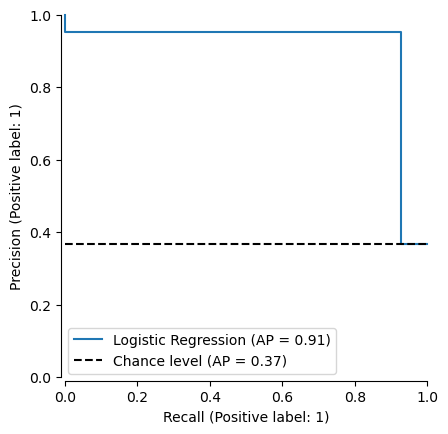

In [88]:
display = PrecisionRecallDisplay.from_predictions(
    y_test, y_preds, 
    name = "Logistic Regression",
    plot_chance_level=True,
    despine = True
)


<p> Relationship between precision and recall can be observed in the stairstep area of the plot.</p>

<p>At the edges of the steps, a small change in the threshold considerably reduces precision, with only
minimal gain in recall </p>


In [89]:
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(gs, X_train, y_train, cv =5,method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train,y_scores)

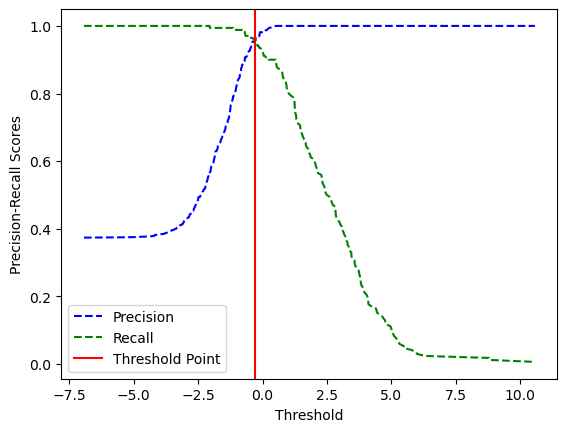

In [90]:
def plot_precision_recall_threshold(precision, recalls, thresholds):
    plt.plot(thresholds, precision[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g--",label="Recall")
    plt.xlabel('Threshold')
    plt.ylabel('Precision-Recall Scores')
    plt.axvline(-0.3,ymin=0, ymax=1.0,color='red',label='Threshold Point')
    plt.legend(loc='lower left')

plot_precision_recall_threshold(precisions,recalls,thresholds)

<p>The precision-recall curve above illustrates what happens with the precision and recall of the classifier at different decision threshold </p>

<p> When the threshold is increased, we have a high precision but then the recall is compromised, for example beyond the threshold of 2.5 </p>

### ROC AUC 

<p>ROC AUC is used to select models for classification based on their performance
with respect to the TPR anad FPR </p>

<p>The diaginal of the ROC is a scenario of random guessing </p>

<p> Any model whose curve is below the diagonal has worse performance than random guessing </p>

<p> A perfect classifier would fall into the top left corner of the graph with a TPR of 1 and an FPR of 0 </p>

<p> Based on the ROC Curve, we can compute the <strong>ROC Area Under the Curve</strong> to characterize the performace of the classifier </p>

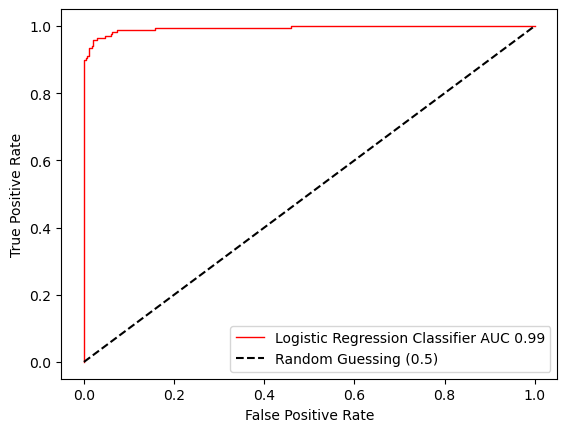

In [91]:
from sklearn.metrics import roc_curve,auc


fpr, tpr, thresholds = roc_curve(y_train, y_scores)
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr,tpr,linewidth=1, label=label,color='red')
    plt.plot([0,1],[0,1],'k--',label='Random Guessing (0.5) ')

plot_roc_curve(fpr,tpr,label=f'Logistic Regression Classifier AUC {round((auc(fpr, tpr)),2)}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

#### Random Forest Classifier

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

In [93]:
pipe_rf = make_pipeline(StandardScaler(),RandomForestClassifier())

In [94]:
## Random Forest Model with cross validation

scores = cross_val_score(estimator = pipe_rf,X = X_train, y= y_train,cv=10, scoring='accuracy')
for i,score in enumerate(scores,start =1):
    print(f'Accuracy fold {i} {round(score*100,3)}')

print(f'Random Forest Accuracy {round(np.mean(scores),3)} +/- {round(np.std(scores),2)}')

Accuracy fold 1 100.0
Accuracy fold 2 100.0
Accuracy fold 3 97.826
Accuracy fold 4 100.0
Accuracy fold 5 93.478
Accuracy fold 6 93.333
Accuracy fold 7 97.778
Accuracy fold 8 97.778
Accuracy fold 9 88.889
Accuracy fold 10 93.333
Random Forest Accuracy 0.962 +/- 0.04


#### Finding the best parameters via a Grid Search

In [95]:
from sklearn.model_selection import GridSearchCV

random_forest = RandomForestClassifier()

param_grid = [
    {'n_estimators':[100, 200, 300, 400, 500]},
    {'max_leaf_nodes':[4,8,12,16,18,20]},
    {'max_features': [10,20,25,30]}
]
grid_rf = GridSearchCV(estimator = random_forest, param_grid = param_grid, scoring ='accuracy', cv=10)

In [96]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=RandomForestClassifier(),
             param_grid=[{'n_estimators': [100, 200, 300, 400, 500]},
                         {'max_leaf_nodes': [4, 8, 12, 16, 18, 20]},
                         {'max_features': [10, 20, 25, 30]}],
             scoring='accuracy')

In [97]:
grid_rf.best_score_

0.9669082125603865

In [98]:
rand_forest = grid_rf.best_estimator_
rand_forest.fit(X_train,y_train)

RandomForestClassifier(max_features=20)

In [100]:
print('Random Forest Accuracy: %.2f ' % rand_forest.score(X_test,y_test))

Random Forest Accuracy: 0.97 


In [148]:
##### Learning curbe for the Random Forest Classifier
from sklearn.model_selection import learning_curve, validation_curve

def plot_learning_curve(estimator,X_train,y_train,cv, desired_acc = 0.98):
    train_sizes, train_scores, test_scores = learning_curve(estimator = estimator,
                                                           X = X_train, 
                                                           y = y_train,
                                                          train_sizes = np.linspace(0.1, 1.0, 10),
                                                          cv = cv,
                                                          n_jobs =1)
    train_mean = np.mean(train_scores, axis =1)
    train_std = np.std(train_scores, axis =1)
    validation_mean = np.mean(test_scores,axis =1)
    validation_std = np.std(test_scores, axis =1)

    STANDARD  = np.array([0.002] * train_std.shape[0], dtype=np.float64)
    
    plt.plot(train_sizes, train_mean, color='red', marker='o', markersize = 3, label ='Training Accuracy')
    plt.fill_between(train_sizes, train_mean + STANDARD, train_mean - STANDARD, alpha=0.15, color='red')
    plt.plot(train_sizes, validation_mean, color='blue', marker='*',markersize=3,label='Validation Accuracy')
    plt.fill_between(train_sizes, validation_mean + STANDARD, validation_mean - STANDARD, alpha = 0.15, color='blue')
    plt.hlines(y = desired_acc, xmin = 10, xmax = 450, linestyles = 'solid', color = 'green', label='Desired Accuracy')
    plt.grid()
    plt.xlabel('Training Samples')
    plt.ylabel('Accuracy Scores')
    plt.legend(loc='lower right')
    plt.show()
    

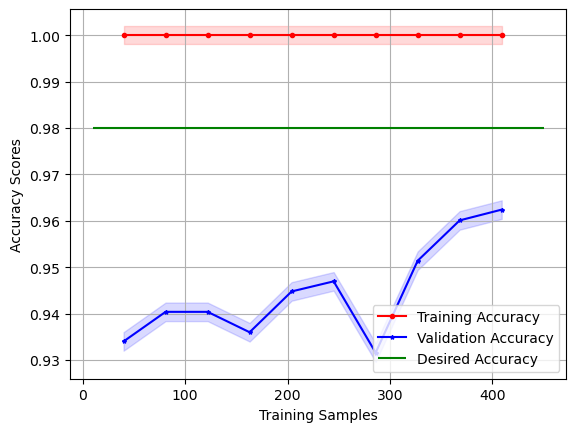

In [149]:
plot_learning_curve(rand_forest,X_train,y_train,cv=10)